# ==========================================================
# FUZZY-BASED STUDENT GRADING SYSTEM
# ==========================================================

In [ ]:
# Install Libraries

!pip install scikit-fuzzy

# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [ ]:
# CREATE TRAINING DATASET

np.random.seed(42)

data_size = 100

attendance = np.random.randint(40, 100, data_size)

assignments = np.random.randint(35, 100, data_size)

exams = np.random.randint(30, 100, data_size)

# Final score calculation
final_score = (
    attendance * 0.2 +
    assignments * 0.3 +
    exams * 0.5
)

# Convert score to grades
grades = []

for score in final_score:

    if score >= 90:
        grades.append("A")

    elif score >= 75:
        grades.append("B")

    elif score >= 60:
        grades.append("C")

    elif score >= 40:
        grades.append("D")

    else:
        grades.append("F")

# Create DataFrame
df = pd.DataFrame({
    'Attendance': attendance,
    'Assignments': assignments,
    'Exams': exams,
    'FinalScore': final_score,
    'Grade': grades
})

print("===================================")
print("STUDENT DATASET")
print("===================================")

print(df.head())

STUDENT DATASET
   Attendance  Assignments  Exams  FinalScore Grade
0          78           96     97        92.9     A
1          91           74     84        82.4     B
2          68           87     85        82.2     B
3          54           58     46        51.2     D
4          82           60     67        67.9     C


In [ ]:
# FUZZY VARIABLES

attendance_var = ctrl.Antecedent(
    np.arange(0, 101, 1),
    'attendance'
)

assignment_var = ctrl.Antecedent(
    np.arange(0, 101, 1),
    'assignments'
)

exam_var = ctrl.Antecedent(
    np.arange(0, 101, 1),
    'exams'
)

grade_var = ctrl.Consequent(
    np.arange(0, 101, 1),
    'grade'
)

# MEMBERSHIP FUNCTIONS

# Attendance
attendance_var['low'] = fuzz.trimf(
    attendance_var.universe,
    [0, 0, 50]
)

attendance_var['medium'] = fuzz.trimf(
    attendance_var.universe,
    [40, 60, 80]
)

attendance_var['high'] = fuzz.trimf(
    attendance_var.universe,
    [70, 100, 100]
)

# Assignments
assignment_var['low'] = fuzz.trimf(
    assignment_var.universe,
    [0, 0, 50]
)

assignment_var['medium'] = fuzz.trimf(
    assignment_var.universe,
    [40, 60, 80]
)

assignment_var['high'] = fuzz.trimf(
    assignment_var.universe,
    [70, 100, 100]
)

# Exams
exam_var['low'] = fuzz.trimf(
    exam_var.universe,
    [0, 0, 50]
)

exam_var['medium'] = fuzz.trimf(
    exam_var.universe,
    [40, 60, 80]
)

exam_var['high'] = fuzz.trimf(
    exam_var.universe,
    [70, 100, 100]
)

# Grade
grade_var['poor'] = fuzz.trimf(
    grade_var.universe,
    [0, 0, 40]
)

grade_var['average'] = fuzz.trimf(
    grade_var.universe,
    [35, 55, 75]
)

grade_var['good'] = fuzz.trimf(
    grade_var.universe,
    [65, 80, 90]
)

grade_var['excellent'] = fuzz.trimf(
    grade_var.universe,
    [85, 100, 100]
)


# FUZZY RULES

rule1 = ctrl.Rule(
    attendance_var['high'] &
    assignment_var['high'] &
    exam_var['high'],
    grade_var['excellent']
)

rule2 = ctrl.Rule(
    attendance_var['medium'] &
    assignment_var['medium'] &
    exam_var['medium'],
    grade_var['good']
)

rule3 = ctrl.Rule(
    attendance_var['low'] |
    assignment_var['low'] |
    exam_var['low'],
    grade_var['poor']
)

rule4 = ctrl.Rule(
    exam_var['high'] &
    assignment_var['medium'],
    grade_var['good']
)

rule5 = ctrl.Rule(
    attendance_var['high'] &
    exam_var['medium'],
    grade_var['average']
)

# CONTROL SYSTEM

grading_ctrl = ctrl.ControlSystem([
    rule1,
    rule2,
    rule3,
    rule4,
    rule5
])

grading_system = ctrl.ControlSystemSimulation(
    grading_ctrl
)


In [ ]:
# TEST WITH NEW INPUT

print("\n===================================")
print("NEW STUDENT GRADE PREDICTION")
print("===================================")

attendance_input = float(
    input("Enter Attendance Percentage: ")
)

assignment_input = float(
    input("Enter Assignment Marks: ")
)

exam_input = float(
    input("Enter Exam Marks: ")
)

# Provide input
grading_system.input['attendance'] = attendance_input

grading_system.input['assignments'] = assignment_input

grading_system.input['exams'] = exam_input

# Compute result
grading_system.compute()

predicted_score = grading_system.output['grade']

print("\nPredicted Final Score:",
      round(predicted_score, 2))

# FINAL GRADE

if predicted_score >= 90:

    final_grade = "A"

elif predicted_score >= 75:

    final_grade = "B"

elif predicted_score >= 60:

    final_grade = "C"

elif predicted_score >= 40:

    final_grade = "D"

else:

    final_grade = "F"

print("Predicted Grade:", final_grade)


NEW STUDENT GRADE PREDICTION
Enter Attendance Percentage: 90
Enter Assignment Marks: 90
Enter Exam Marks: 90

Predicted Final Score: 94.58
Predicted Grade: A


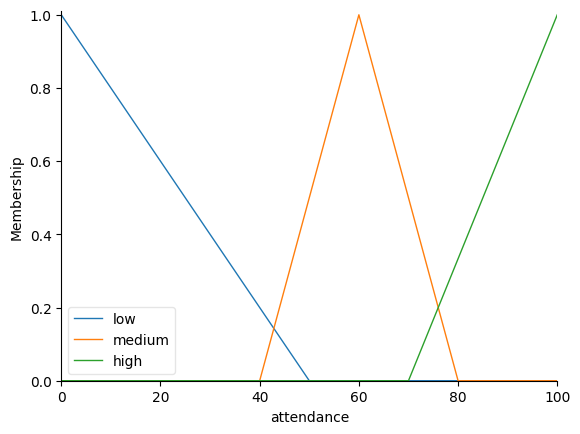

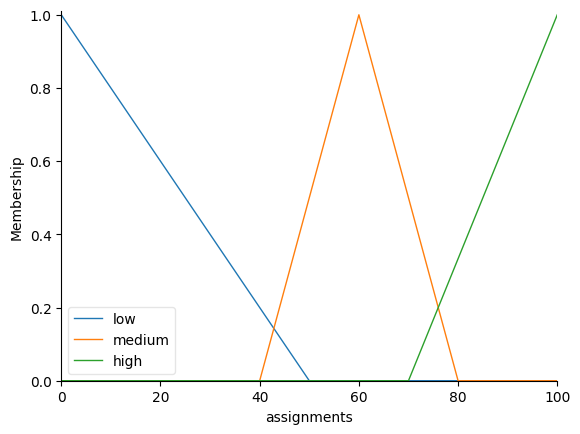

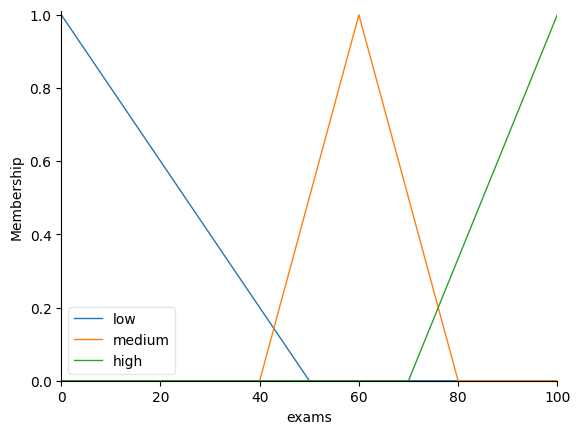

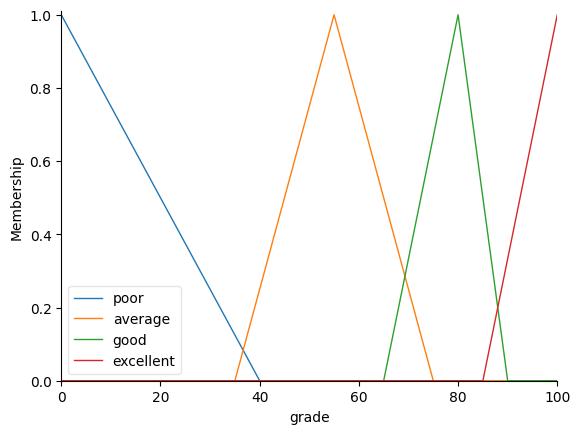


PROJECT SUMMARY
System Type : Fuzzy Logic Grading System
Inputs Used : Attendance, Assignments, Exams
Output      : Student Grade
Prediction  : Real-Time Grade Prediction

Project Executed Successfully!


In [ ]:
# VISUALIZATION

attendance_var.view()
assignment_var.view()
exam_var.view()
grade_var.view()

plt.show()

# PROJECT SUMMARY

print("\n===================================")
print("PROJECT SUMMARY")
print("===================================")

print("System Type : Fuzzy Logic Grading System")

print("Inputs Used : Attendance, Assignments, Exams")

print("Output      : Student Grade")

print("Prediction  : Real-Time Grade Prediction")

print("\nProject Executed Successfully!")